##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

import warnings
warnings.filterwarnings("ignore")

##Load Dataset

In [3]:
df = pd.read_excel("baseline_forecastingdataset.xlsx")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        731 non-null    datetime64[ns]
 1   Units Sold  731 non-null    int64         
 2   SMA_7       725 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 17.3 KB


##Convert Date ColumnConvert Date Column

In [4]:
df = df.sort_values("Date")

##Create time series

In [5]:
daily_sales = (
    df.groupby("Date")["Units Sold"]
      .sum()
      .sort_index()
)

daily_sales.head()

,Units Sold
Date,
2022-01-01,14484
2022-01-02,13415
2022-01-03,13681
2022-01-04,14084
2022-01-05,12572


##Plot Historical Demand

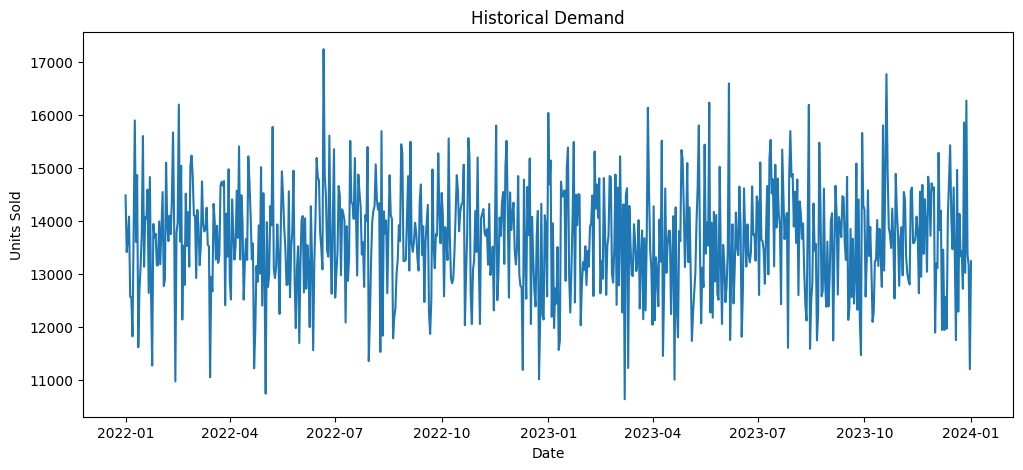

In [6]:
plt.figure(figsize=(12,5))
plt.plot(daily_sales)
plt.title("Historical Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.show()

##Split Train & Test

In [7]:
train_size = int(len(daily_sales)*0.8)
train = daily_sales[:train_size]
test = daily_sales[train_size:]

##Train Arima

In [8]:
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()